In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df=pd.read_csv('/content/Walmart Data Analysis and Forcasting.csv')

In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


/tmp/ipykernel_636/3602643140.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Store',y='Fuel_Price',palette='pastel')


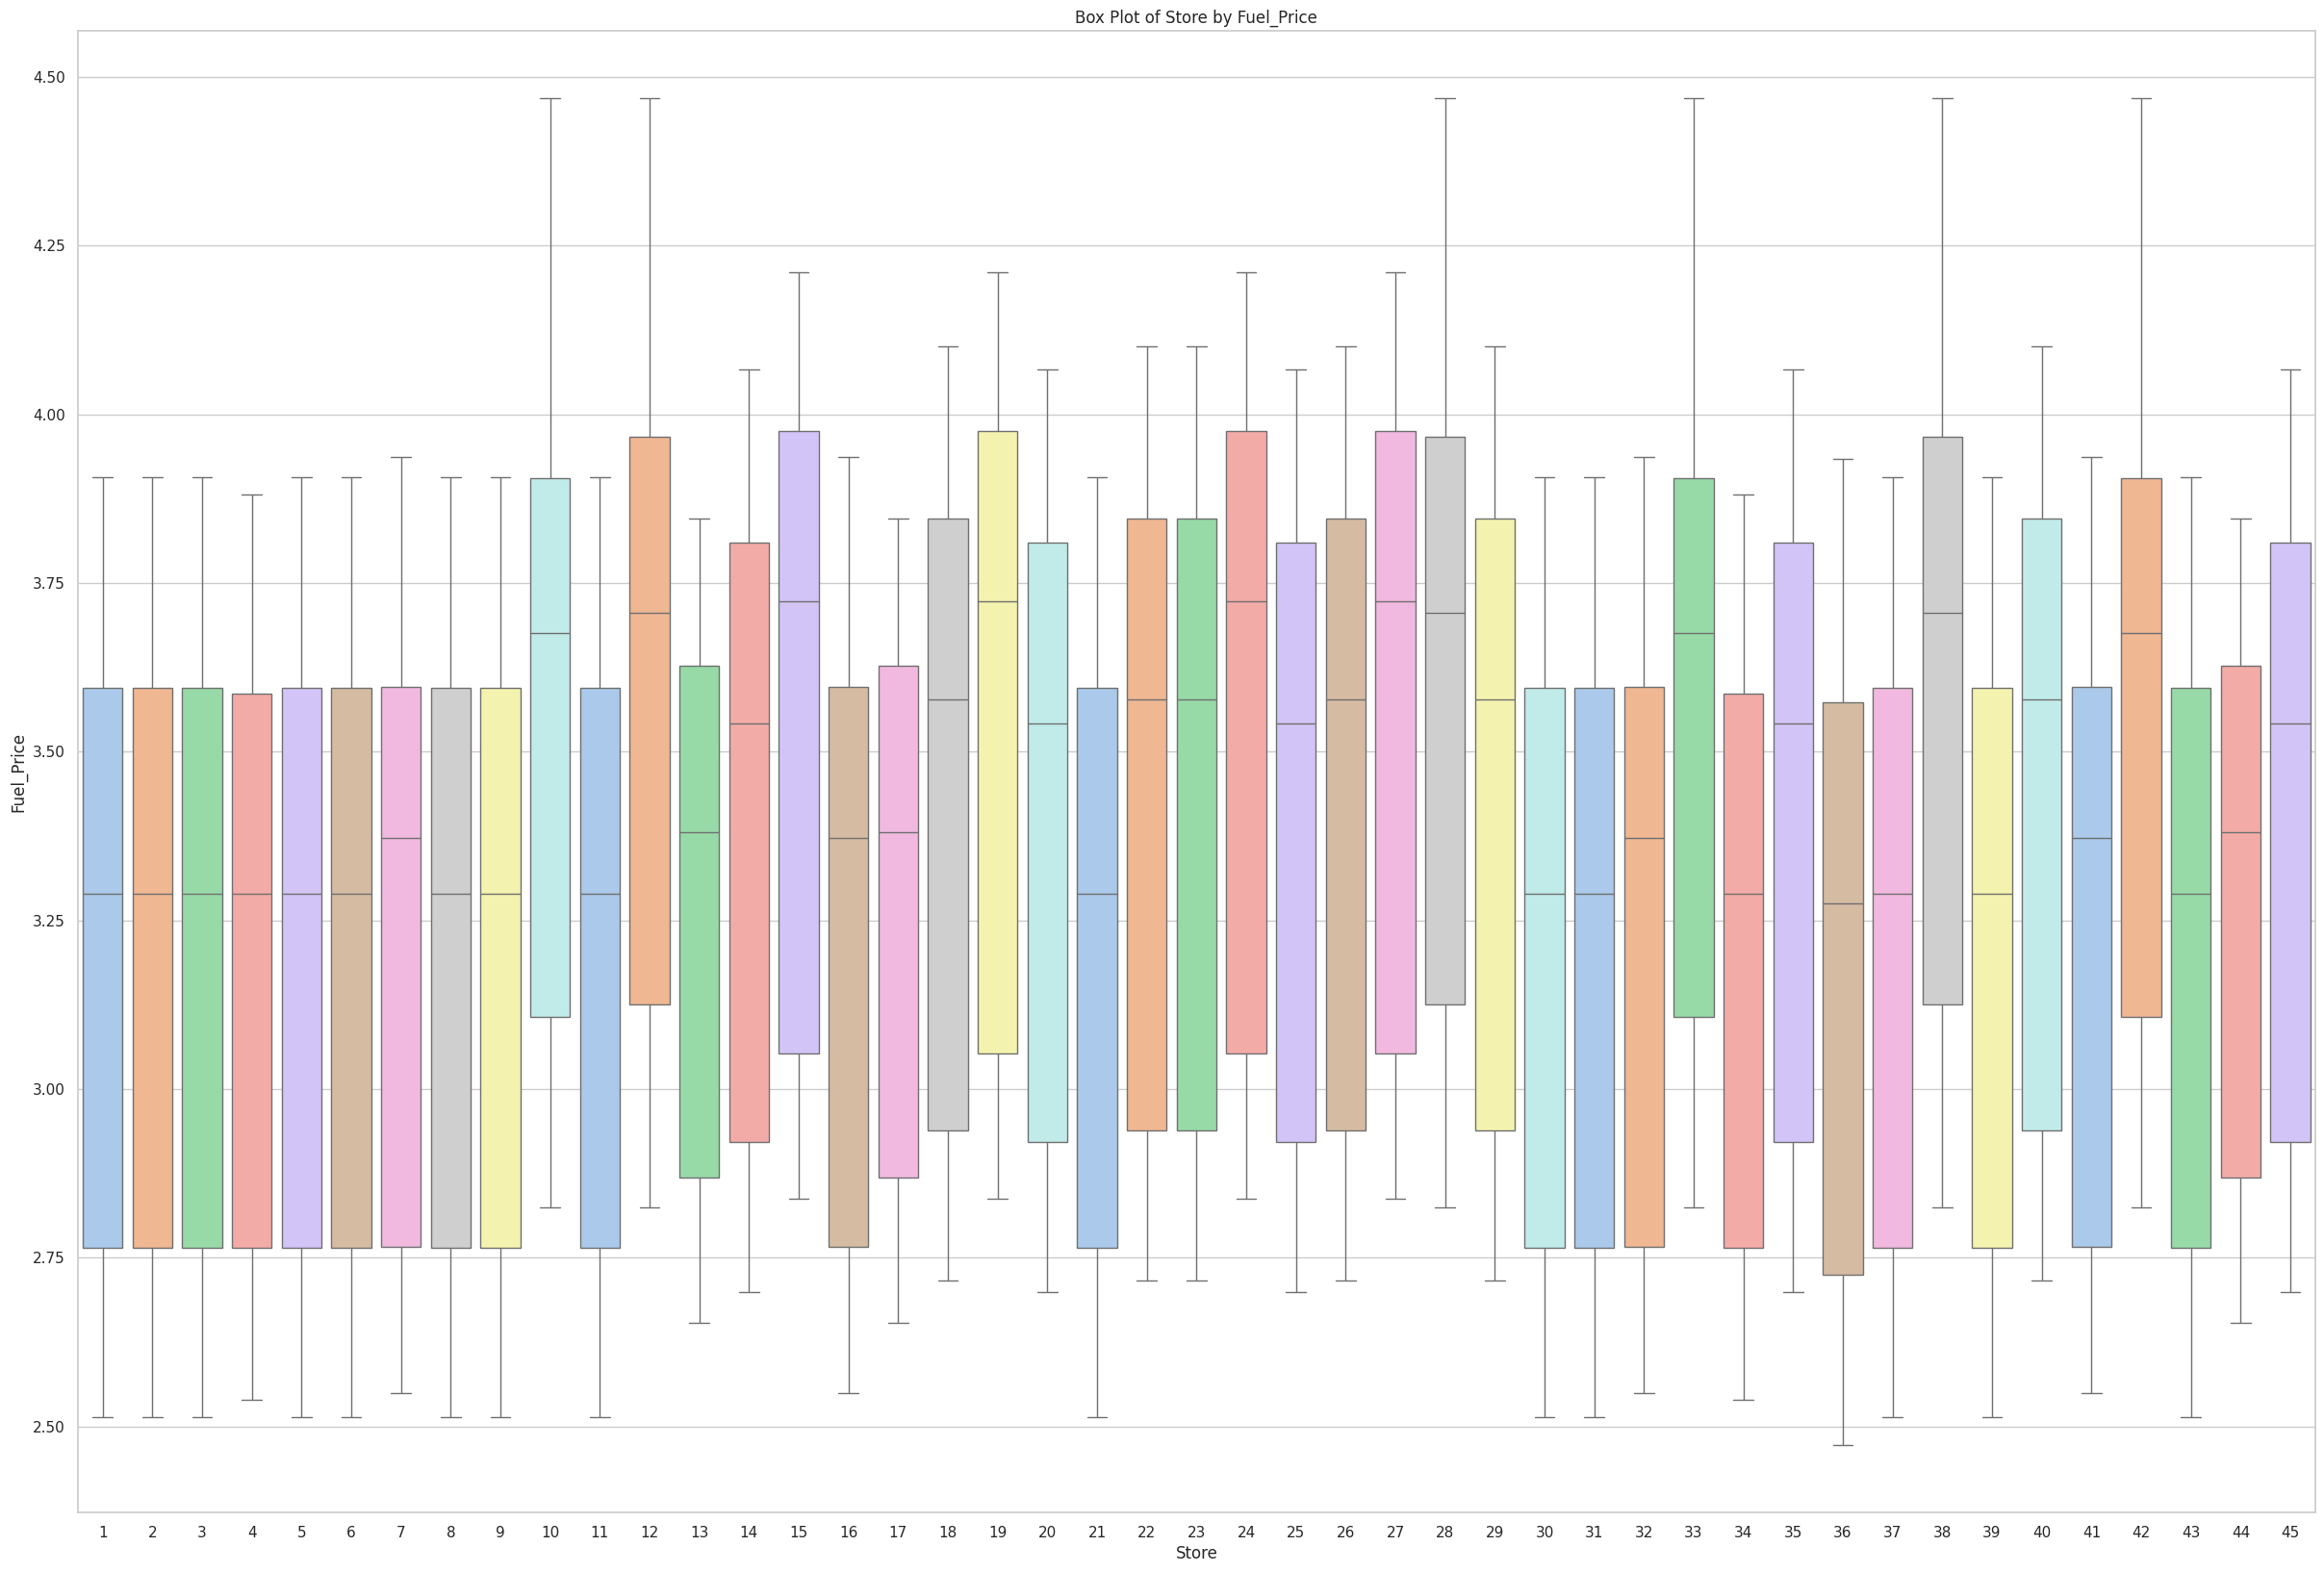

In [ ]:
#Box Plot

sns.set(style="whitegrid")

#create boxplot
plt.figure(figsize=(30, 20))
sns.boxplot(data=df,x='Store',y='Fuel_Price',palette='pastel')

#set plot title and labels
plt.title('Box Plot of Store by Fuel_Price',fontsize=12)
plt.xlabel('Store',fontsize=12)
plt.ylabel('Fuel_Price',fontsize=12)

#show plot
plt.show()

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format='%d-%m-%Y')

# Extract useful features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [ ]:
df.drop(columns=['Date'], inplace=True)

x = df.drop(columns=['Weekly_Sales'])
y = df['Weekly_Sales']

In [ ]:
num_cols = x.select_dtypes(include=['number']).columns

scaler = StandardScaler()
x[num_cols] = scaler.fit_transform(x[num_cols])


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)**0.5

print("R² Score:", r2)
print("MSE:", mse)

R² Score: 0.155485902615203
MSE: 521597.61442135595


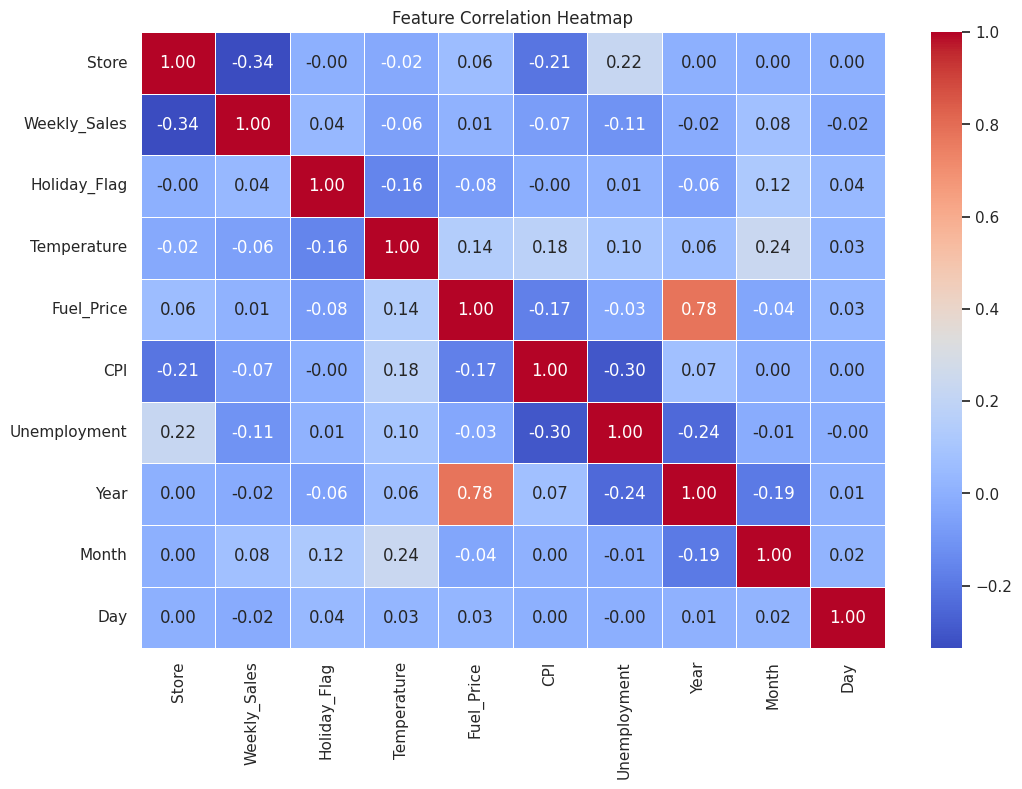

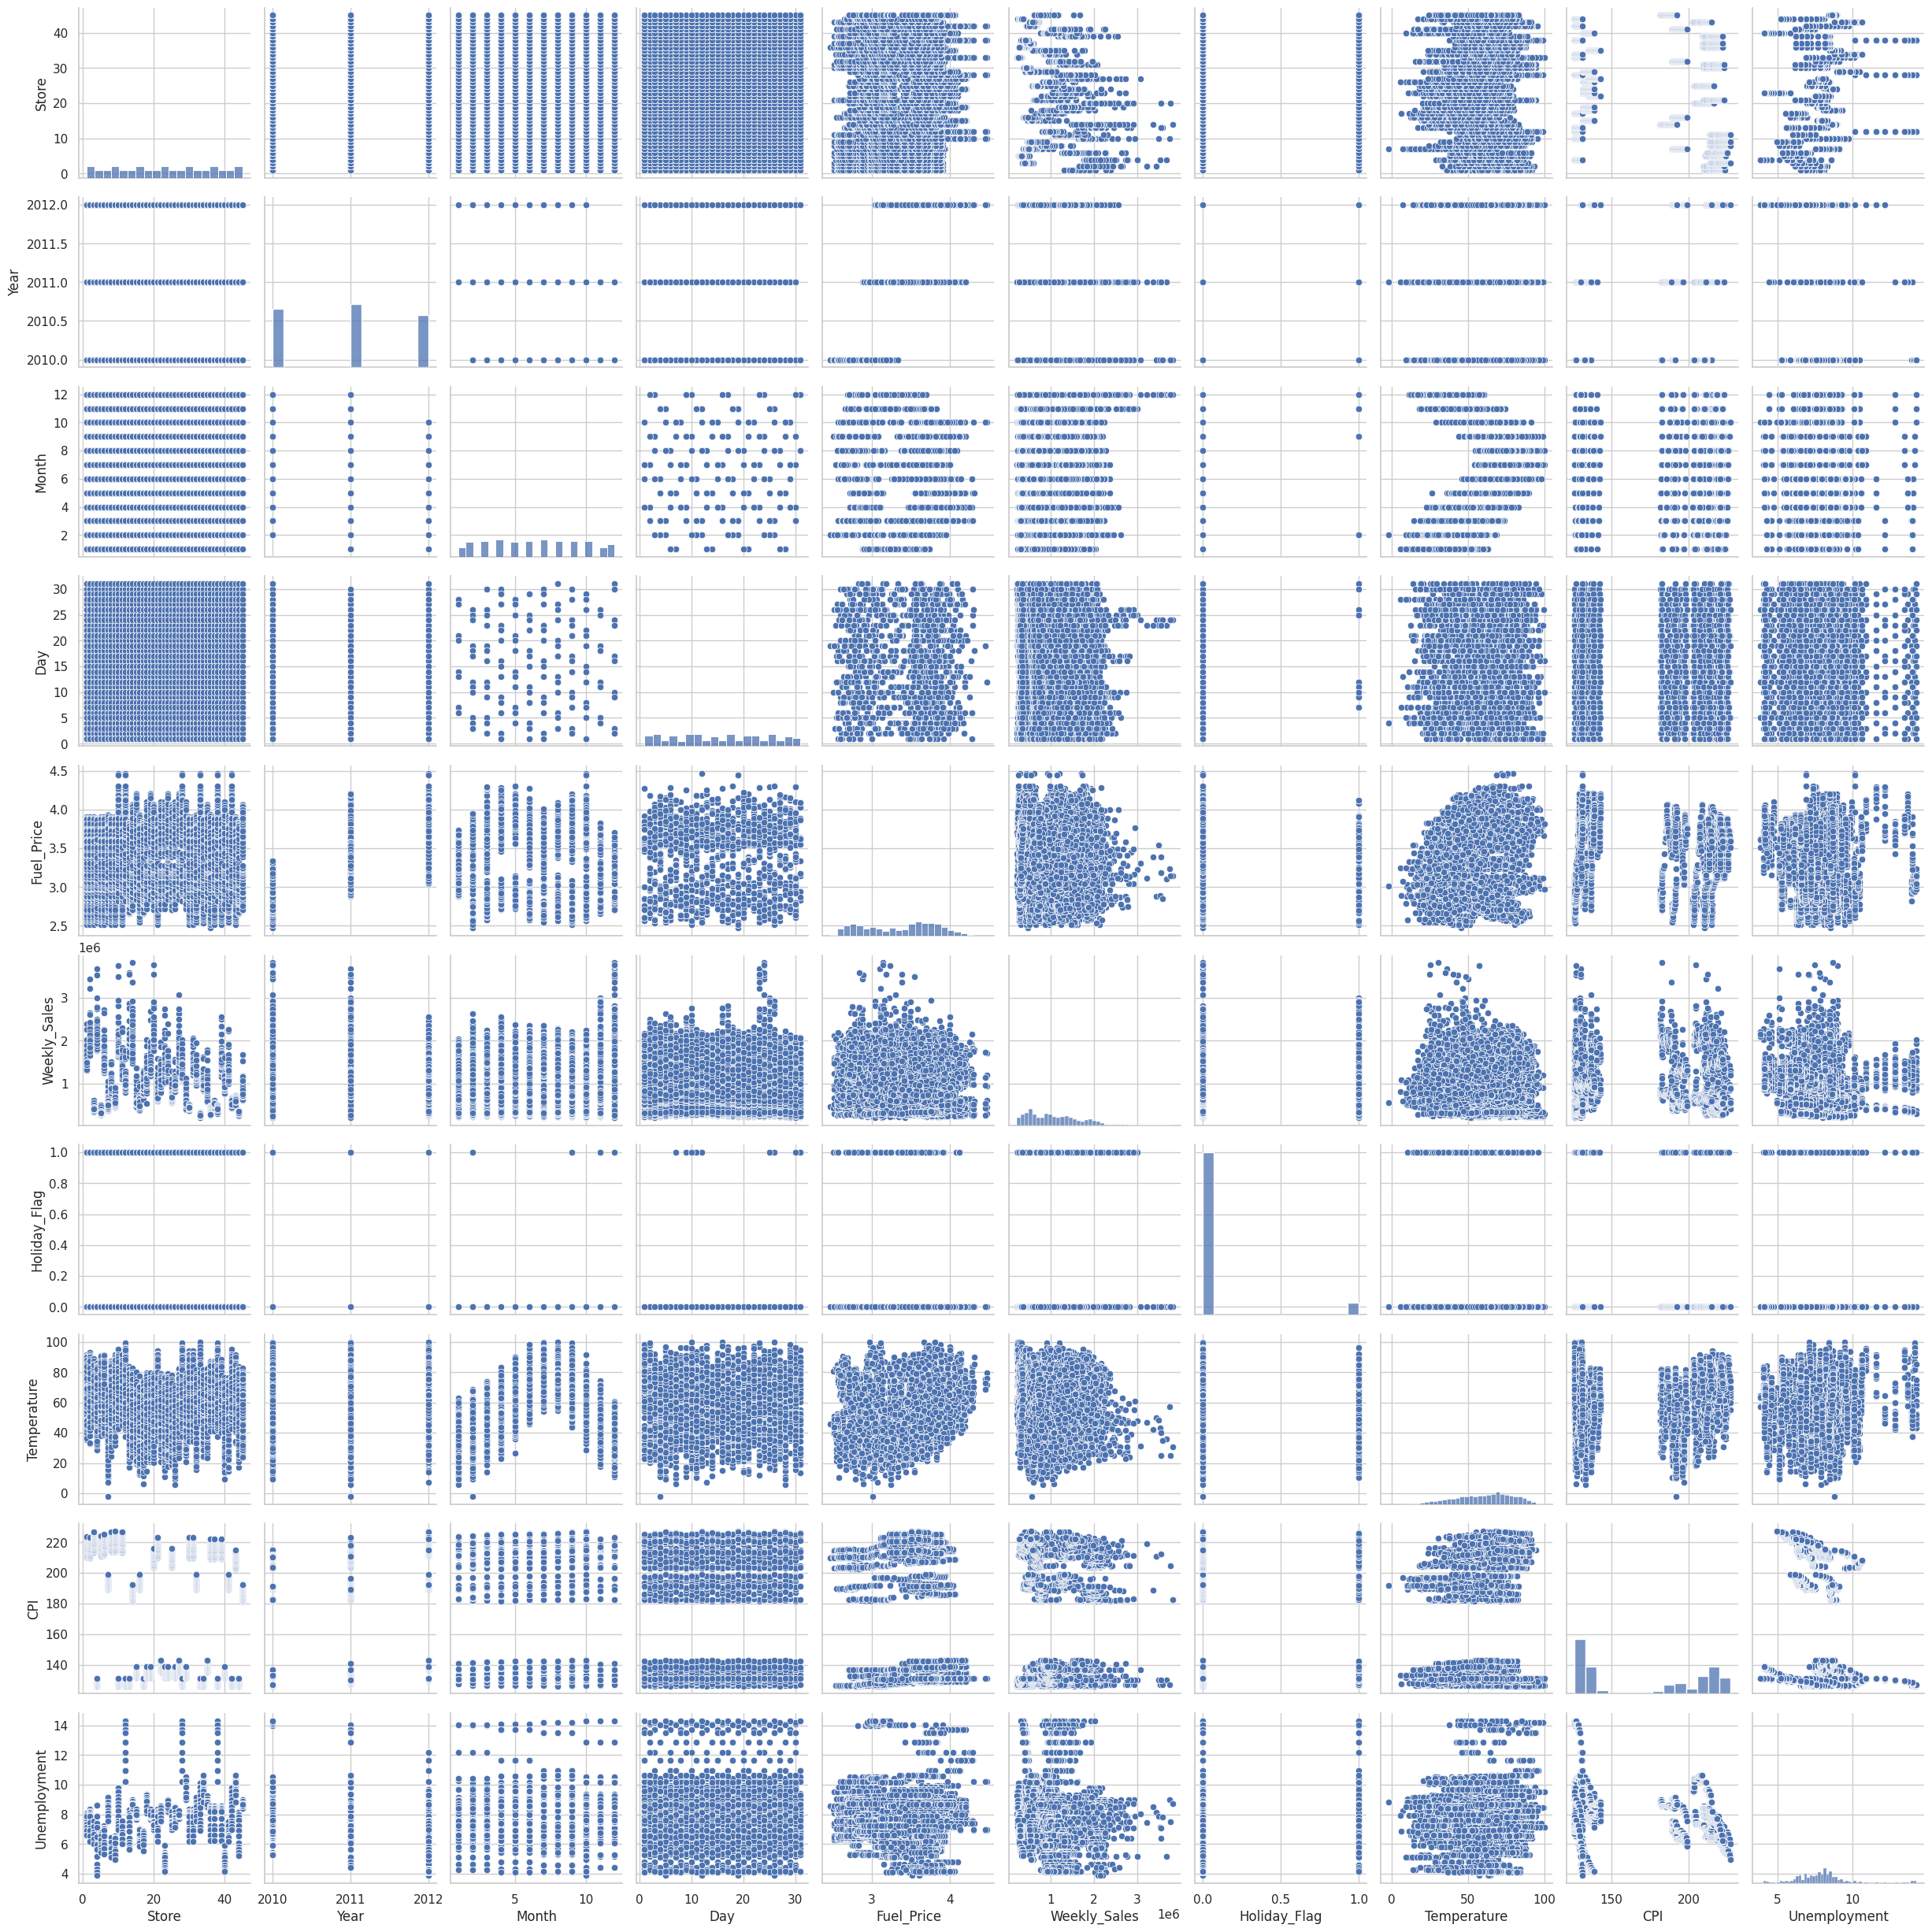

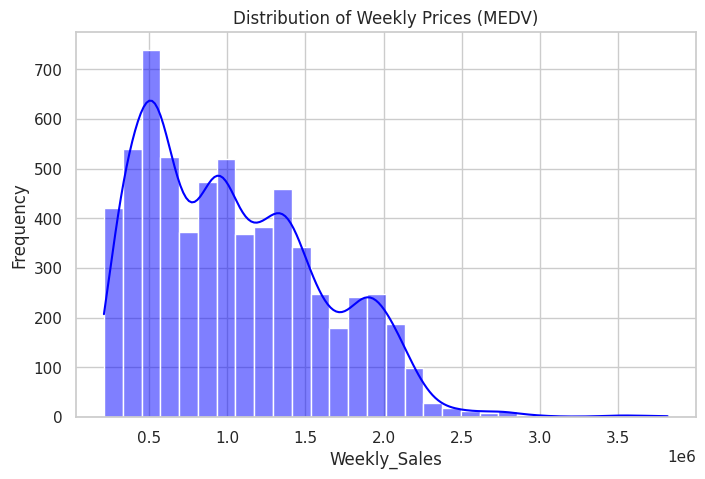

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['Store',
                 'Year',
                 'Month',
                 'Day',
                 'Fuel_Price',
                 'Weekly_Sales',
                 'Holiday_Flag',
                 'Temperature',
                 'CPI',
                 'Unemployment']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Prices ")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales"])  # All columns except target
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1555
RMSE: 521597.6144


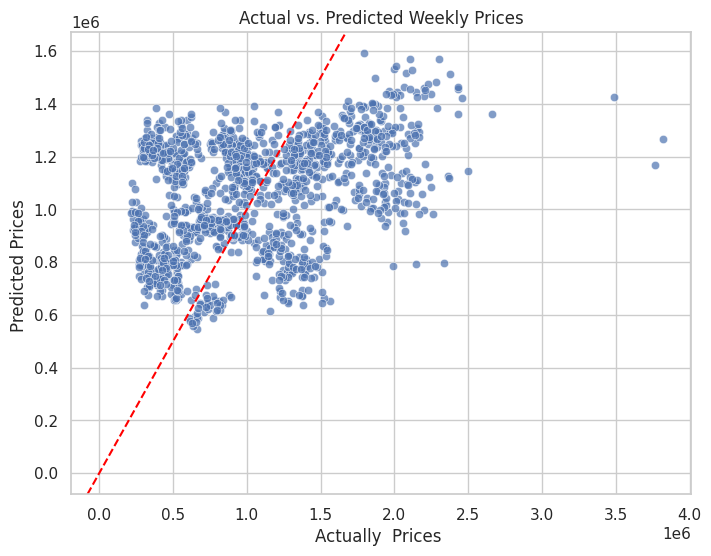

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y= y_pred,alpha=0.7)
plt.xlabel("Actually  Prices ")
plt.ylabel("Predicted Prices ")
plt.title("Actual vs. Predicted Weekly Prices")
plt.title("Actual vs. Predicted Weekly Prices")
plt.axline([0,0],[1,1],color='red',linestyle="--")
plt.show()

In [ ]:
from scipy.stats import skew

In [ ]:
skewness=df.skew()

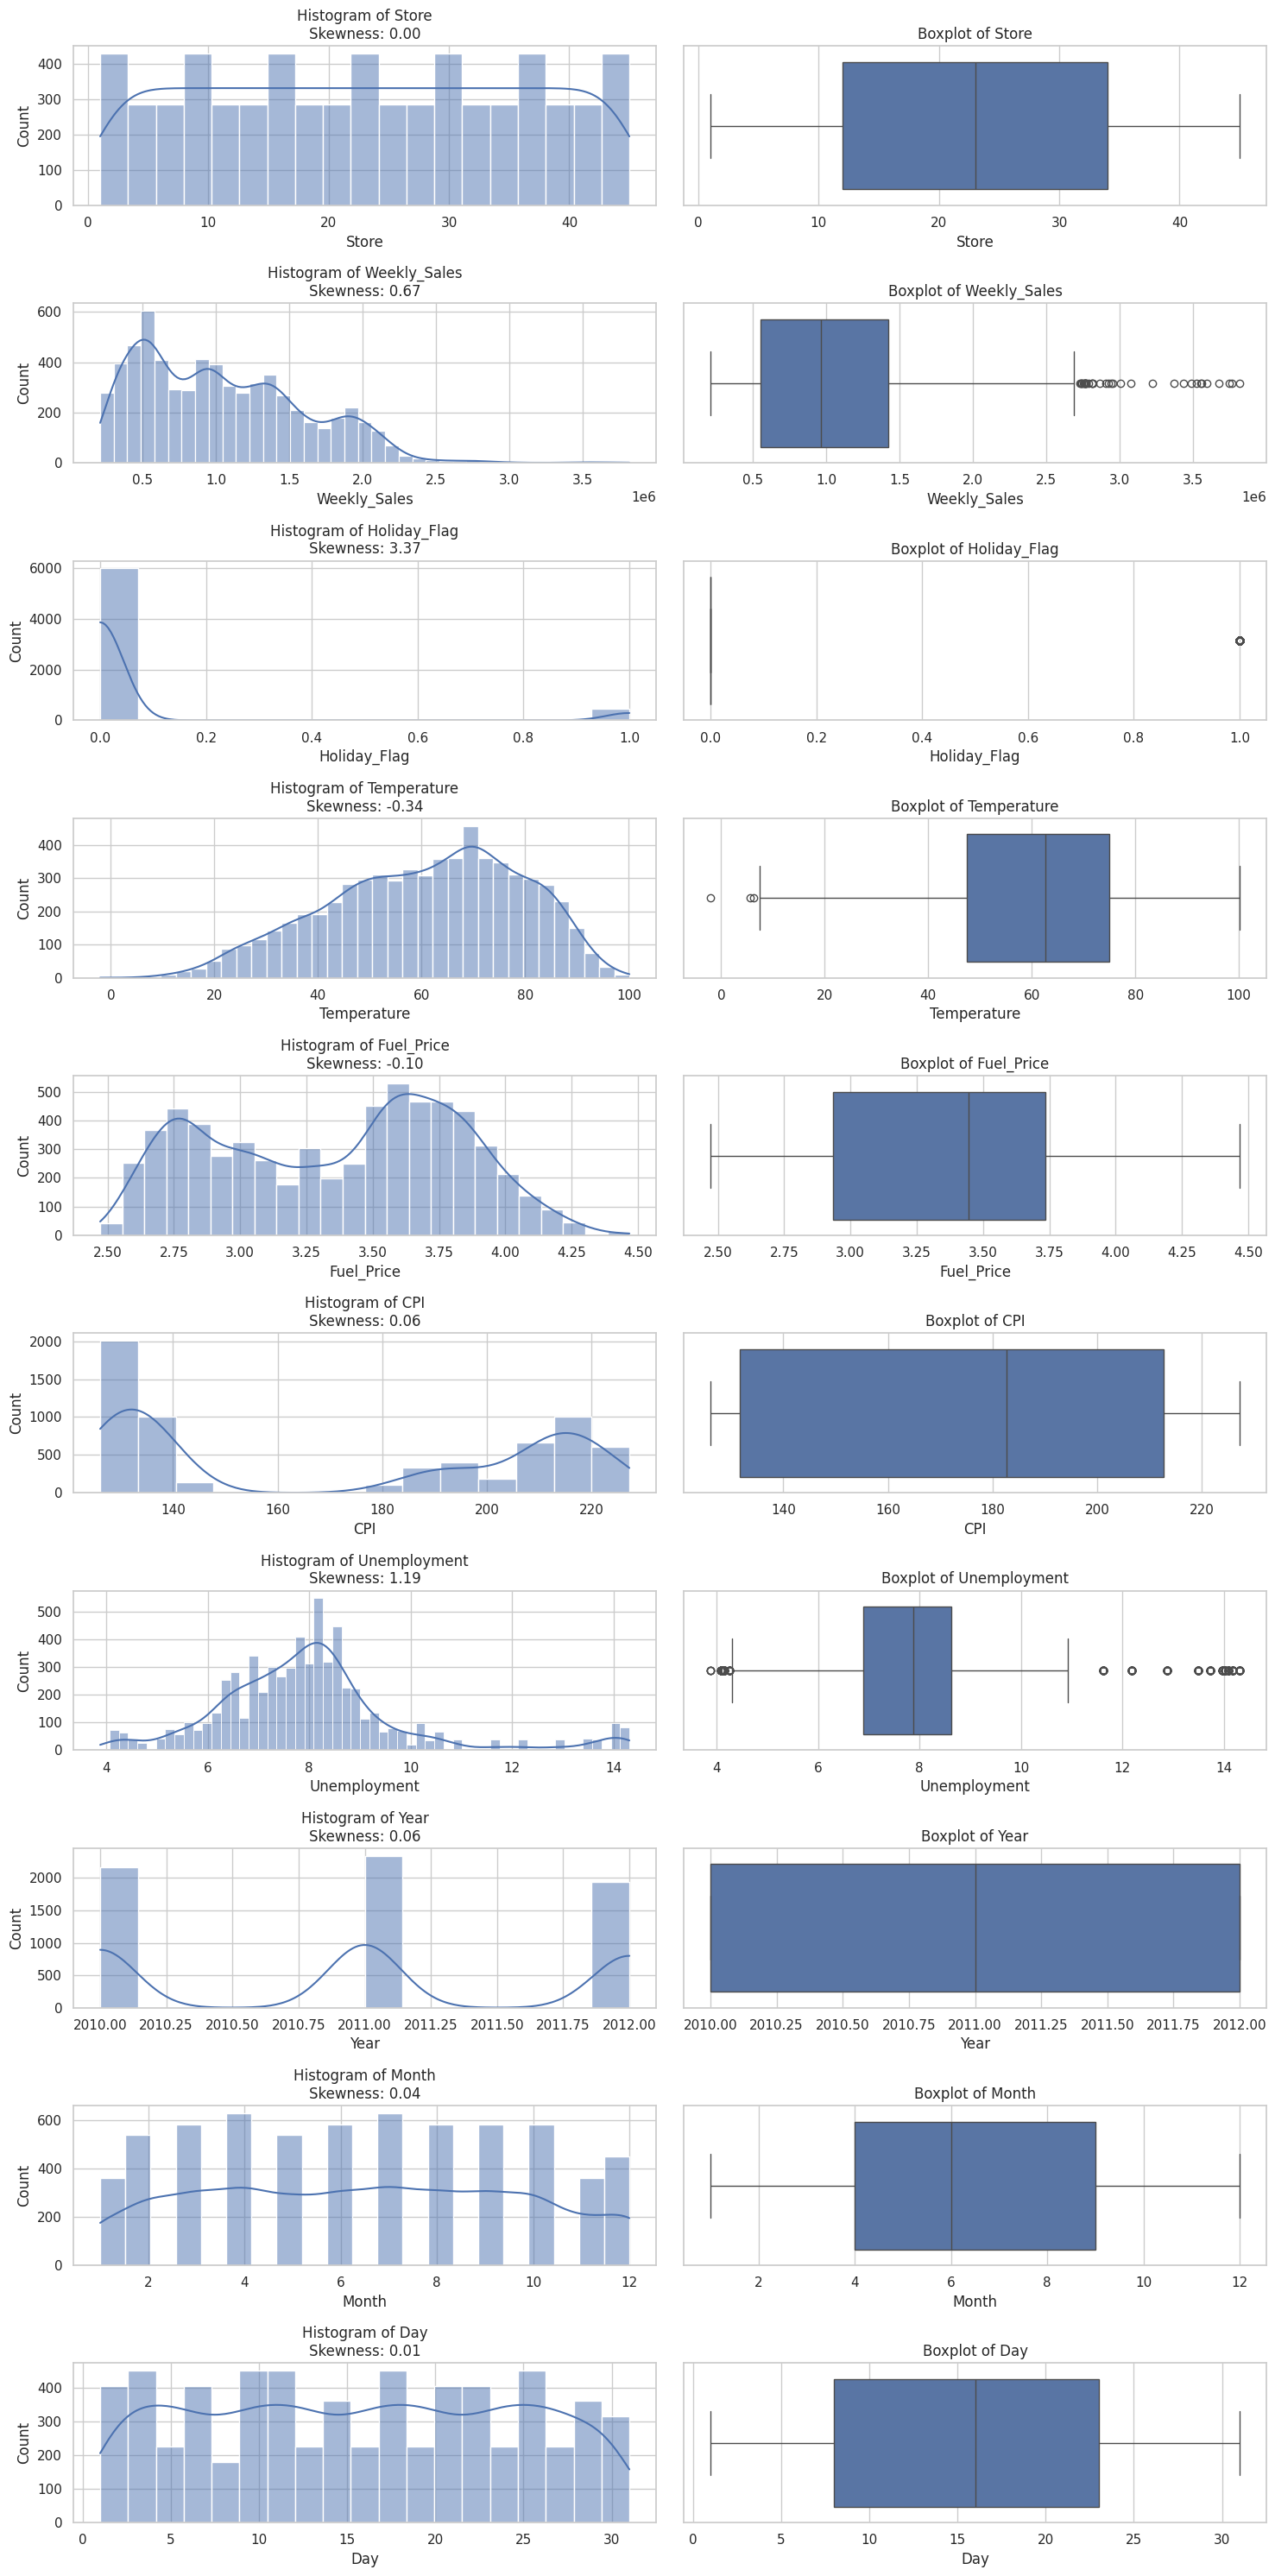

In [ ]:
num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(df.columns):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f"Histogram of {col}\nSkewness: {skewness[col]:.2f}")


  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
df.skew()

,0
Store,0.000000
Weekly_Sales,0.668362
Holiday_Flag,3.373499
Temperature,-0.336768
Fuel_Price,-0.096158
CPI,0.063492
Unemployment,1.188144
Year,0.062642
Month,0.039568
Day,0.008512


In [ ]:
import numpy as np

In [ ]:
skewed_cols=df.skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Hihly Skewed coloumns:\n",highly_skewed)
print("Negatively Skewed coloumns:\n",negatively_skewed)

Hihly Skewed coloumns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed coloumns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [ ]:
df[highly_skewed]=(df[highly_skewed].apply(lambda x: np.log1p(x)))

In [ ]:
from sklearn.preprocessing import PowerTransformer

In [ ]:
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [ ]:
df.skew()

,0
Store,-0.228157
Weekly_Sales,-0.049912
Holiday_Flag,3.373499
Temperature,-0.141684
Fuel_Price,-0.055815
CPI,0.010477
Unemployment,0.226991
Year,0.000000
Month,-0.140278
Day,-0.209117


In [ ]:
# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales"])  # All columns except target
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1336
RMSE: 0.9428


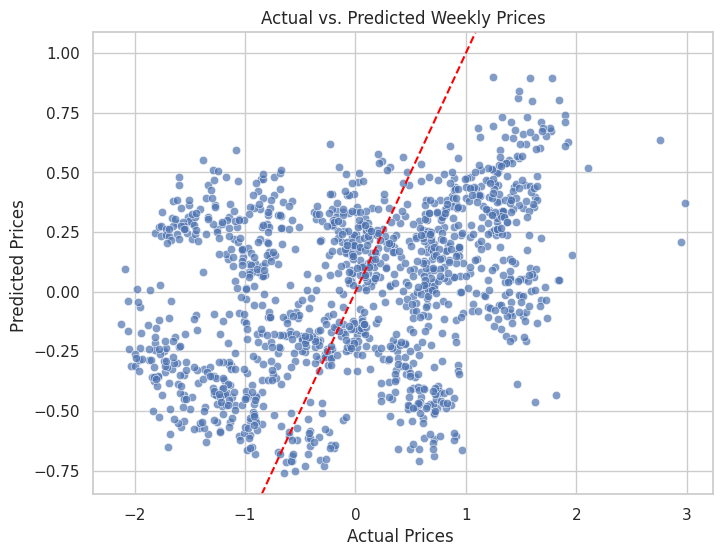

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y= y_pred,alpha=0.7)
plt.xlabel("Actual Prices ")
plt.ylabel("Predicted Prices ")
plt.title("Actual vs. Predicted Weekl Prices")
plt.title("Actual vs. Predicted Weekly Prices")
plt.axline([0,0],[1,1],color='red',linestyle="--")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

y_pred=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print(f"Random Forest R**2 Score:{r2:4f}")
print(f"Random Forest RMSE:{rmse:4f}")

Random Forest R**2 Score:0.976185
Random Forest RMSE:0.156313


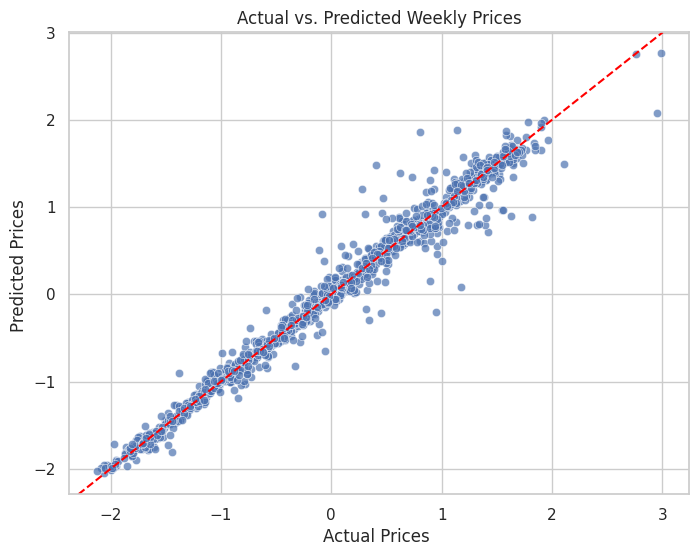

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y= y_pred,alpha=0.7)
plt.xlabel("Actual Prices ")
plt.ylabel("Predicted Prices ")
plt.title("Actual vs. Predicted Weekl Prices")
plt.title("Actual vs. Predicted Weekly Prices")
plt.axline([0,0],[1,1],color='red',linestyle="--")
plt.show()

In [ ]:
print("Training columns:")
print(list(x.columns))

print("\nInput columns:")
print(list(input_data.columns))

Training columns:
['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day']

Input columns:
['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day']


In [ ]:
print(num_cols)
print(type(num_cols))

10
<class 'int'>


In [ ]:
num_cols = x.select_dtypes(include=['number']).columns

print(num_cols)

Index(['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'Year', 'Month', 'Day'],
      dtype='object')


In [ ]:
print(input_data)

print("\nShape:", input_data.shape)

print("\nDtypes:")
print(input_data.dtypes)

prediction = model.predict(input_data)

print("\nPrediction:", prediction)

   Store  Holiday_Flag  Temperature  Fuel_Price   CPI  Unemployment    Year  \
0   33.0           1.0         33.0        33.0  22.0           2.0  2021.0   

   Month  Day  
0    2.0  5.0  

Shape: (1, 9)

Dtypes:
Store           float64
Holiday_Flag    float64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
Year            float64
Month           float64
Day             float64
dtype: object

Prediction: [-15.75523842]


In [ ]:
print(df['Weekly_Sales'].head())
print(df['Weekly_Sales'].describe())

0    1.062778
1    1.060635
2    1.023306
3    0.757367
4    0.950729
Name: Weekly_Sales, dtype: float64
count    6.435000e+03
mean     4.593408e-16
std      1.000078e+00
min     -2.139207e+00
25%     -8.514777e-01
50%      4.800900e-02
75%      7.717413e-01
max      2.986214e+00
Name: Weekly_Sales, dtype: float64


In [ ]:
print("R2 Score =", r2)

R2 Score = 0.9761845324802129


In [ ]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Predicted:", prediction[0])
print("Actual:", y_test.iloc[0])

Predicted: 0.18762538721312577
Actual: 0.3534557601520099


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# User Input
store = float(input("Enter Store: "))
holiday_flag = float(input("Enter Holiday Flag (0/1): "))
temperature = float(input("Enter Temperature: "))
fuel_price = float(input("Enter Fuel Price: "))
cpi = float(input("Enter CPI: "))
unemployment = float(input("Enter Unemployment: "))
year = float(input("Enter Year: "))
month = float(input("Enter Month: "))
day = float(input("Enter Day: "))

# Create dataframe
input_data = pd.DataFrame({
    'Store': [store],
    'Holiday_Flag': [holiday_flag],
    'Temperature': [temperature],
    'Fuel_Price': [fuel_price],
    'CPI': [cpi],
    'Unemployment': [unemployment],
    'Year': [year],
    'Month': [month],
    'Day': [day]
})

# Scale input
input_data[num_cols] = scaler.transform(input_data[num_cols])

# Predict
prediction = model.predict(input_data)[0]

print(f"\nPredicted Weekly Sales (scaled): {prediction:.4f}")

Enter Store: 3
Enter Holiday Flag (0/1): 1
Enter Temperature: 33
Enter Fuel Price: 22
Enter CPI: 11
Enter Unemployment: 4
Enter Year: 2021
Enter Month: 4
Enter Day: 22

Predicted Weekly Sales (scaled): 3.0164


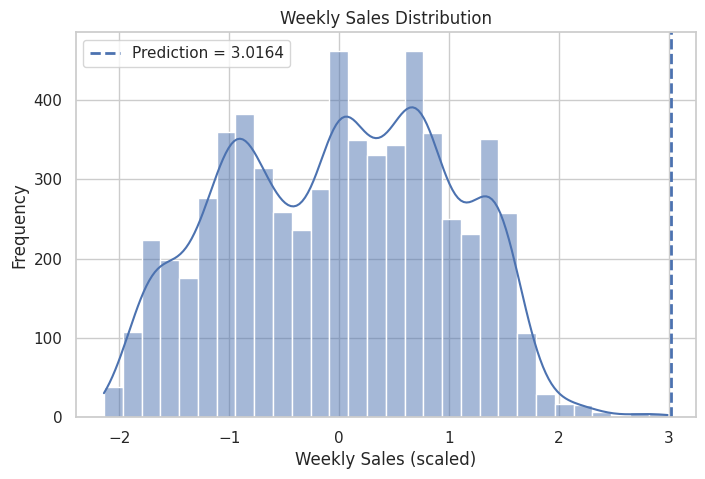

Prediction is HIGH compared to most sales values.


In [ ]:

# Histogram comparison
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True)

# Mark prediction on histogram
plt.axvline(prediction, linestyle='--', linewidth=2,
            label=f'Prediction = {prediction:.4f}')

plt.title("Weekly Sales Distribution")
plt.xlabel("Weekly Sales (scaled)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Position analysis
mean_sales = y.mean()
std_sales = y.std()

if prediction > mean_sales + std_sales:
    print("Prediction is HIGH compared to most sales values.")
elif prediction < mean_sales - std_sales:
    print("Prediction is LOW compared to most sales values.")
else:
    print("Prediction is within the normal sales range.")